In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("../data/processed/wine_processed.csv")

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale data for SGD and SVC
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# SGD
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)

# SVC
svc_model = SVC(kernel="rbf", random_state=42)
svc_model.fit(X_train_scaled, y_train)
svc_pred = svc_model.predict(X_test_scaled)

In [4]:
df = pd.read_csv("../data/processed/wine_processed.csv")

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# SGD
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)

# SVC
svc_model = SVC(kernel="rbf", random_state=42)
svc_model.fit(X_train_scaled, y_train)
svc_pred = svc_model.predict(X_test_scaled)

In [6]:
rf_acc = accuracy_score(y_test, rf_pred)
sgd_acc = accuracy_score(y_test, sgd_pred)
svc_acc = accuracy_score(y_test, svc_pred)

print("Random Forest:", rf_acc)
print("SGD:", sgd_acc)
print("SVC:", svc_acc)

Random Forest: 0.5735294117647058
SGD: 0.5343137254901961
SVC: 0.6029411764705882


In [7]:
print("="*50)
print("Random Forest")
print(classification_report(y_test, rf_pred))

print("="*50)
print("SGD")
print(classification_report(y_test, sgd_pred))

print("="*50)
print("SVC")
print(classification_report(y_test, svc_pred))

Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.64      0.62      0.63        87
           6       0.54      0.63      0.58        82
           7       0.52      0.46      0.49        24
           8       0.00      0.00      0.00         3

    accuracy                           0.57       204
   macro avg       0.28      0.29      0.28       204
weighted avg       0.55      0.57      0.56       204

SGD
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.56      0.72      0.63        87
           6       0.53      0.52      0.53        82
           7       0.50      0.08      0.14        24
           8       1.00      0.33      0.50         3

    accuracy                           0.53       204
   ma

c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

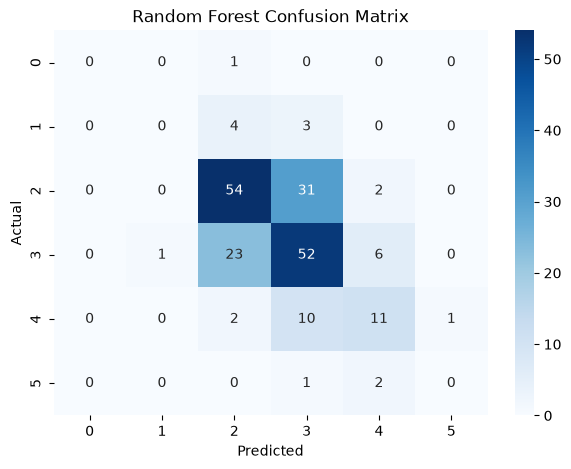

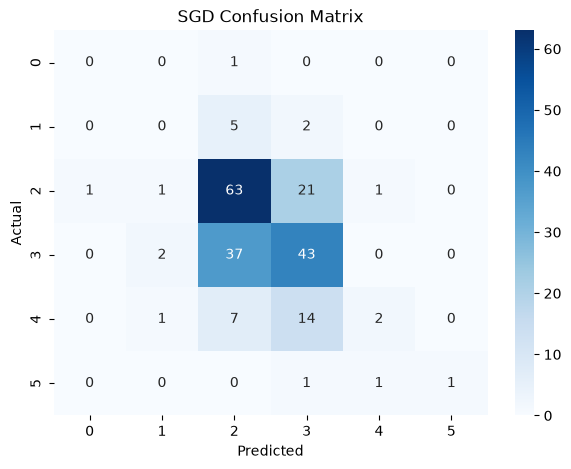

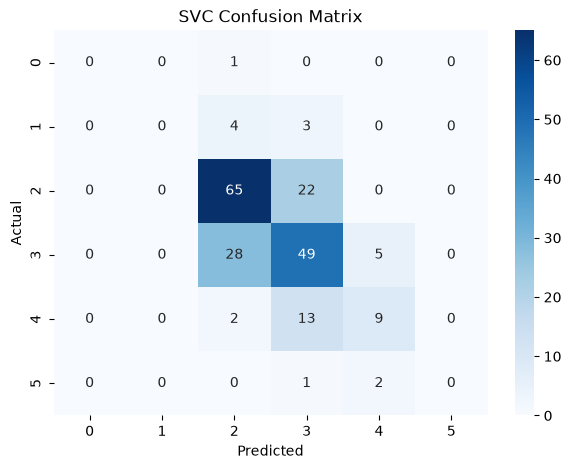

In [8]:
models = {
    "Random Forest": rf_pred,
    "SGD": sgd_pred,
    "SVC": svc_pred
}

for name, prediction in models.items():

    plt.figure(figsize=(7,5))

    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [9]:
rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

sgd_cv = cross_val_score(
    sgd_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

svc_cv = cross_val_score(
    svc_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV:", rf_cv.mean())
print("SGD CV:", sgd_cv.mean())
print("SVC CV:", svc_cv.mean())

Random Forest CV: 0.5736839563411571
SGD CV: 0.5367946678785125
SVC CV: 0.6031356509884116


In [10]:
comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "SGD",
        "SVC"
    ],

    "Accuracy":[
        rf_acc,
        sgd_acc,
        svc_acc
    ],

    "Cross Validation":[
        rf_cv.mean(),
        sgd_cv.mean(),
        svc_cv.mean()
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Cross Validation
2,SVC,0.602941,0.603136
0,Random Forest,0.573529,0.573684
1,SGD,0.534314,0.536795


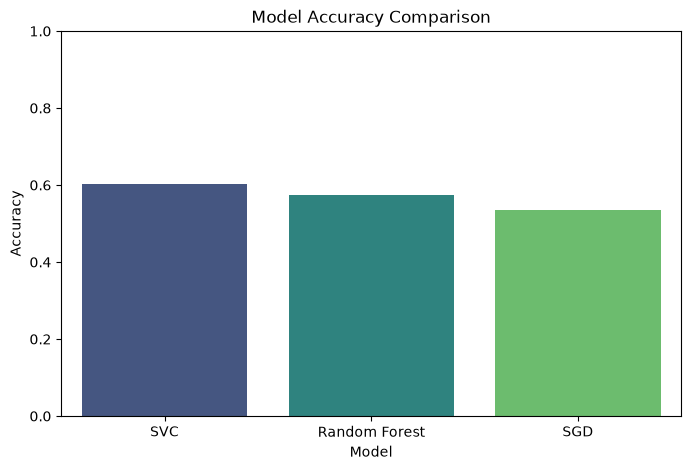

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.show()

In [12]:
comparison.to_csv(
    "../reports/results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.
